In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import onnx
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import to_onnx
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
from skl2onnx import convert_sklearn

### Visualise some features to decide how to split them or morph them

### Set up the Metamorphic and EP relationships to be tested

### Now we set up the good and bad models

We will use an AdaBoost model for both, since we believe the major problem is using features that are either badly recorded or shouldn't be relevant to the predicition of fraud risk.

In [79]:
# Let's load the dataset
data = pd.read_csv('../data/investigation_train_large_checked.csv')
details = pd.read_csv('../data/data_description.csv', encoding='latin1')

# Rename columns to english for ease of use
data.rename(columns=dict(zip(details['Feature (nl)'], details['Feature (en)'])), inplace=True)
data.drop(columns=["Ja", "Nee"], inplace=True)
data.fillna(data.mean(), inplace=True)

# Let's specify the features and the target
y_train = data['checked'].astype(int)
X_train = data.drop(['checked'], axis=1)
X_train = X_train.astype(np.float32)

In [80]:
# Set up Column correlation 
from sklearn.feature_selection import mutual_info_classif


def topk_corr(X: pd.DataFrame, A: str, k=100, stop_threshold=0.08, method="pearson"):
    target = X[A] 
    corrs = X.corrwith(target, method=method).dropna()
    top = corrs.abs().sort_values(ascending=False).head(k)
    return top[top > stop_threshold]

In [81]:
# Set up the Column selector for the good model
from sklearn.compose import ColumnTransformer

def ColumnSelector(bad_columns, bad, col_no, threshold):

    corr_bad_columns = set()

    for col in bad_columns:
        corr_bad_columns.update(topk_corr(X_train, col, 100, 0.08).index.to_list())

    corr_bad_columns = list(corr_bad_columns)

    name_to_idx = {c: i for i, c in enumerate(X_train.columns)}
    
    cols = [name_to_idx[c] for c in corr_bad_columns]

    if bad == False:

        good_columns = [col for col in X_train.columns if col not in corr_bad_columns]

        cols = [name_to_idx[c] for c in good_columns]

    return ColumnTransformer(
        transformers=[
            ("keep", "passthrough", cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
)

In [82]:
# Define hyperparameters and models

# Hyperparameters
bad_columns = ['person_age_at_investigation', 'personal_qualities_days_since_language_requirement', 'exemption_days_hist_due to_your_medical_conditions', 
               'relationship_child_current_number', 'pla_history_social_effort', 'person_gender_woman']
col_no = 100
threshold = 0.08

# Models
bad_model = Pipeline(steps=[('column filter', ColumnSelector(bad_columns, bad=True, col_no = col_no, threshold = threshold)), 
                            ('classification', GradientBoostingClassifier(n_estimators=100, random_state=42))])

good_model = Pipeline(steps=[('column filter', ColumnSelector(bad_columns, bad = False, col_no = col_no, threshold = threshold)), 
                            ('classification', GradientBoostingClassifier(n_estimators=100, random_state=42))])


c:\Users\radud\OneDrive\Desktop\Uni Stuff\Master\SET\ml-testing-rotterdam-risk\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\radud\OneDrive\Desktop\Uni Stuff\Master\SET\ml-testing-rotterdam-risk\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Correlation with label
person_age_at_investigation -> 0.19706604719586104
personal_qualities_days_since_language_requirement -> 0.16824999031315194
exemption_days_hist_due to_your_medical_conditions -> 0.14503366392638922
relationship_child_current_number -> 0.10181172549649752
pla_history_social_effort -> 0.0881619344053751
person_gender_woman -> 0.006344137782187033


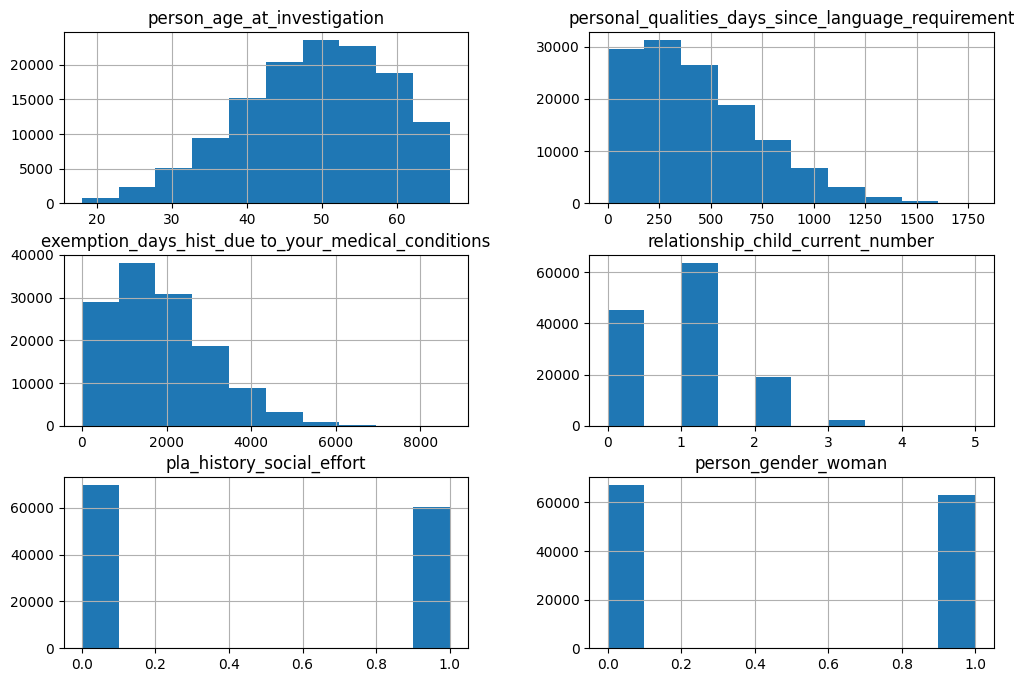

In [83]:
# Display feature correlation and shape
print('Correlation with label')
for col in bad_columns:
    print(f'{col} -> {abs(data[col].corr(data["checked"]))}')

data[bad_columns].hist(figsize=(12,8));

In [84]:
# Train the bad model
bad_model.fit(X_train, y_train);

In [85]:
# Train the good models
good_model.fit(X_train, y_train);

In [86]:
# Let's convert the model to ONNX
bad_model_onnx = convert_sklearn(
    bad_model, initial_types=[('X', FloatTensorType((None, X_train.shape[1])))],
    target_opset=12)
good_model_onnx = convert_sklearn(
    good_model, initial_types=[('X', FloatTensorType((None, X_train.shape[1])))],
    target_opset=12)

# Let's save the model
onnx.save(bad_model_onnx, "m1.onnx")
onnx.save(good_model_onnx, "m2.onnx")
